# Test spectackle Package Imports


In [1]:
# Assumes: pip install -e . from project root

path set ok: /Users/hph/Research/Projects/ACES/Spectral_Decomp_ML/ACES_SpecTackle/src


In [2]:
### Imports
import numpy as np
print("numpy OK", end=" ... ")
import torch
print("torch OK", end=" ... ")

from spectackle.config import deep_update, set_cpu_safety
from spectackle.data import BASE_CFG, make_loaders, SyntheticSpectraDataset, generate_spectrum, DEFAULT_GEN
from spectackle.models import CountNet1D, CountNet1D_Classify
from spectackle.training import train_scheme_b, train_scheme_c
from spectackle.plotting import plot_example, collect_count_predictions, collect_predictions_bc

print("spectackle OK")

numpy OK ... torch OK ... spectackle OK


In [3]:
### Config + data
set_cpu_safety(1)  ### Avoid CPU oversubscription → kernel crash on macOS
cfg = deep_update(BASE_CFG, {})
Kmax = int(cfg["max_components"])

train_loader, val_loader = make_loaders(cfg, n_train=500, n_val=200, bs_train=64, bs_val=64)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Config OK. Kmax={Kmax}, device={device}")

Config OK. Kmax=10, device=cpu


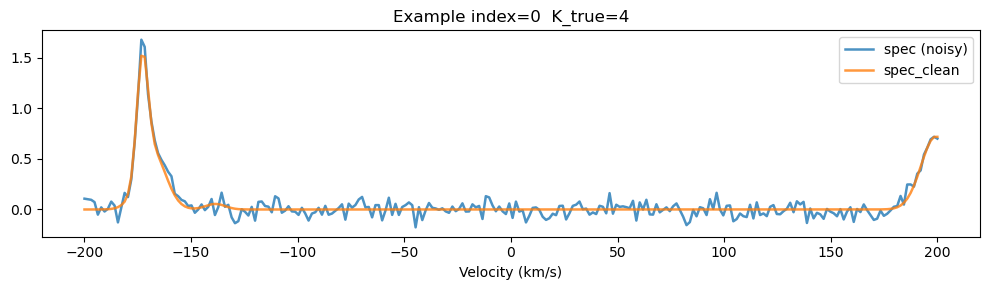

In [4]:
### plot one example
plot_example(val_loader.dataset, idx=0)

In [5]:
### Train both schemes (1 epoch)
print("=== Scheme B ===")
model_b = CountNet1D(width=32)
model_b = train_scheme_b(model_b, train_loader, val_loader, device=device, epochs=1, log_every=20, Kmax=Kmax)

print("\n=== Scheme C ===")
model_c = CountNet1D_Classify(Kmax=Kmax, width=32)
model_c = train_scheme_c(model_c, train_loader, val_loader, device=device, epochs=1, log_every=20)

=== Scheme B ===
  [B] epoch 1 val_K_MAE 3.445

=== Scheme C ===
  [C] epoch 1 val_acc 0.165  val_K_MAE(argmax) 3.455  val_K_MAE(E[K]) 2.561


In [6]:
### Collect predictions
y_true, y_b, y_c_argmax, y_c_exp = collect_predictions_bc(
    model_b, model_c, val_loader, device, Kmax, max_batches=20
)

mae_b = np.abs(y_b - y_true).mean()
mae_c = np.abs(y_c_argmax - y_true).mean()
print(f"Scheme B MAE: {mae_b:.3f}")
print(f"Scheme C MAE: {mae_c:.3f}")
print("\nTest complete.")

Scheme B MAE: 3.445
Scheme C MAE: 3.455

Test complete.
